In [ ]:
# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
# Load Dataset

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Missing Value Analysis

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

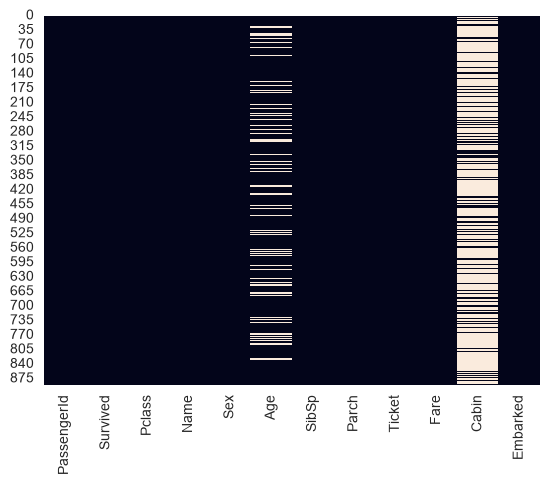

In [7]:
sns.heatmap(df.isnull(), cbar= False)
plt.show()

In [ ]:
# Handle Missing Value

In [10]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [11]:
df['Age'].isnull().sum()

np.int64(0)

In [12]:
df.drop('Cabin', axis=1, inplace=True)

In [14]:
df['Embarked']= df['Embarked'].fillna(df['Embarked'].mode()[0])

In [15]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Univariate Analysis

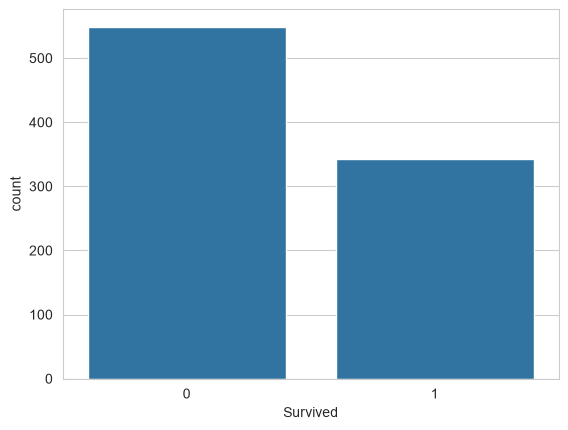

In [48]:
# survived vs died (0 : died, 1: survived)

sns.countplot(x='Survived', data=df)
plt.savefig(
    "survived_vs_died.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

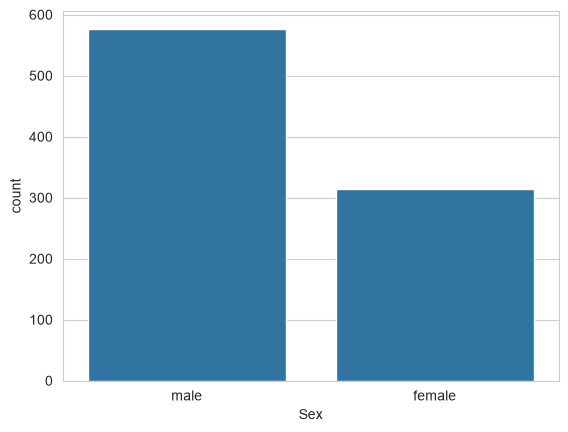

In [49]:
# gender distribution 

sns.countplot(x='Sex', data=df)
plt.savefig(
    "gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

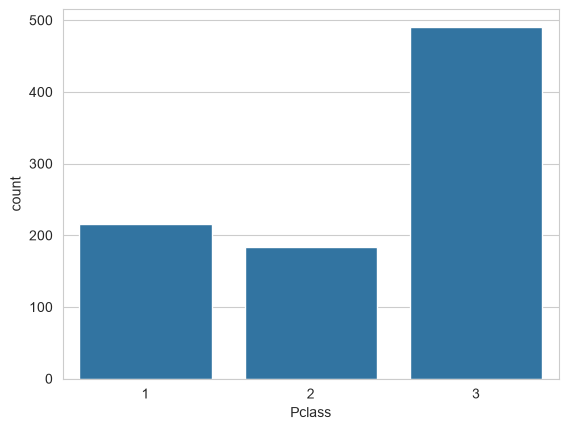

In [50]:
# class distribution

sns.countplot(x='Pclass', data=df)
plt.savefig(
    "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

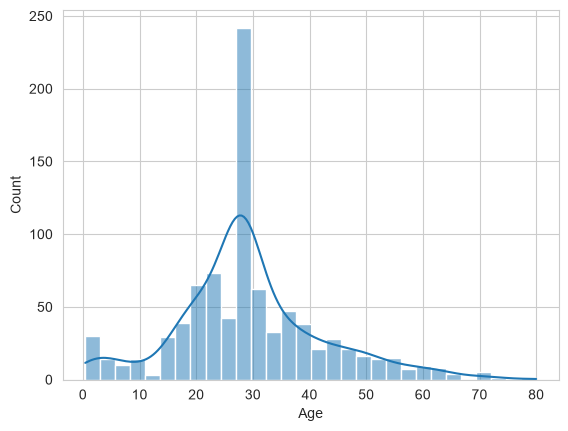

In [51]:
# Age distribution

sns.histplot(df['Age'], kde=True)
plt.savefig(
    "age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

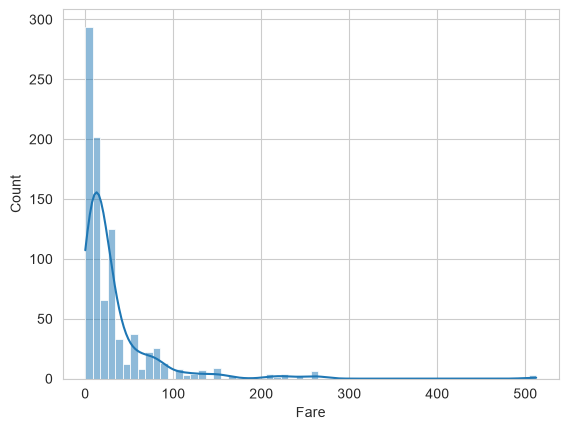

In [52]:
# Fare distribution

sns.histplot(df['Fare'], kde=True)
plt.savefig(
    "Fare_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

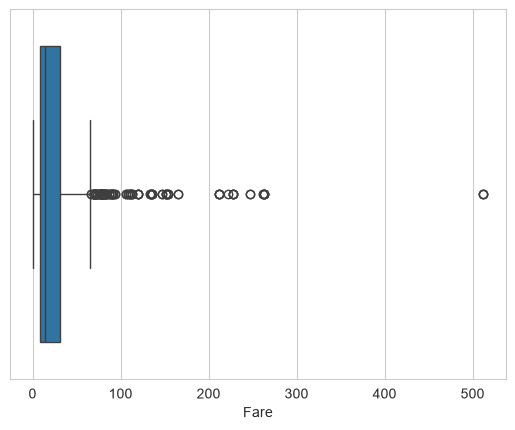

In [42]:
# Outliers

sns.boxplot(x=df['Fare'])
plt.show()

In [41]:
# Bivariate Analysis

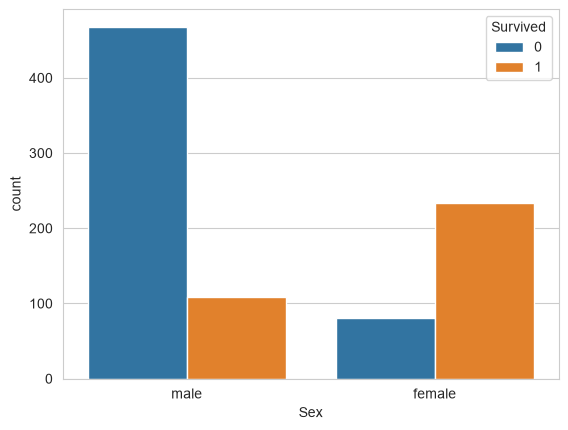

In [53]:
# gender vs survival

sns.countplot(x='Sex', hue='Survived', data=df)
plt.savefig(
    "gender_vs_survival.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

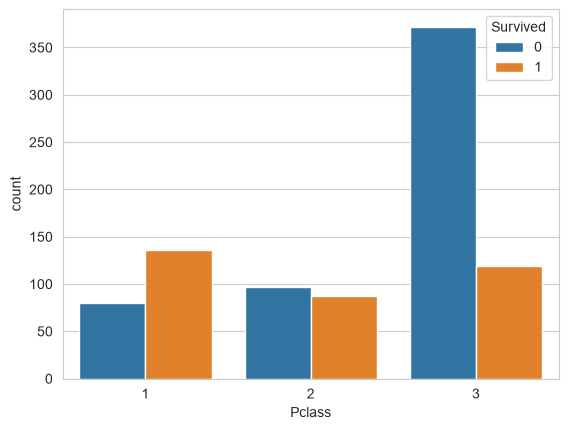

In [54]:
# class vs survival

sns.countplot(x='Pclass', hue='Survived', data=df)
plt.savefig(
    "class_vs_survival.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

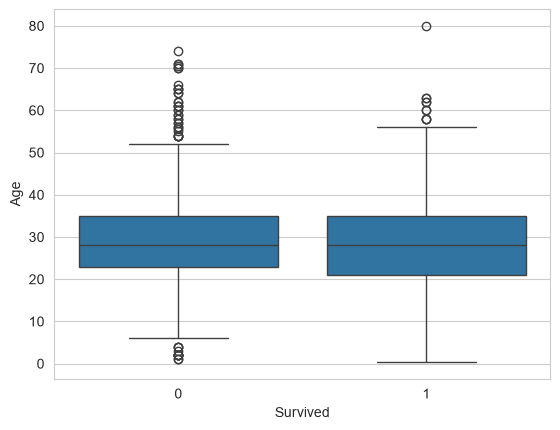

In [55]:
# Age vs survival

sns.boxplot(x='Survived', y='Age', data=df)
plt.savefig(
    "age_vs_survival.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

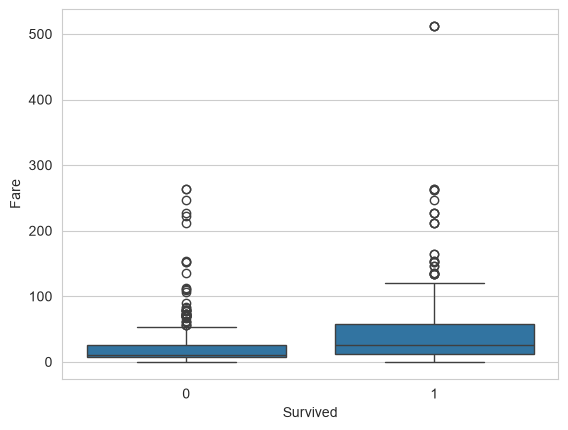

In [56]:
# Fare vs survival

sns.boxplot(x='Survived', y='Fare', data=df)
plt.savefig(
    "Fare_vs_survival.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [27]:
# Multivariate Analysis

In [47]:
# Correlation Matrix

df_encoded = df.copy()

df_encoded['Sex'] = df_encoded['Sex'].map({
    'male':0,
    'female':1
})

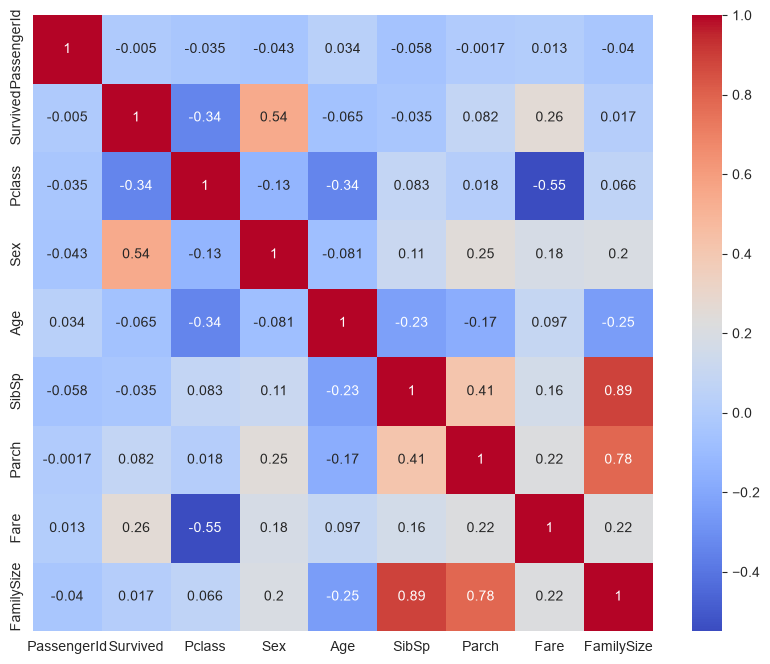

In [57]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_encoded.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.savefig(
    "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
# Feature Engineering

In [31]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

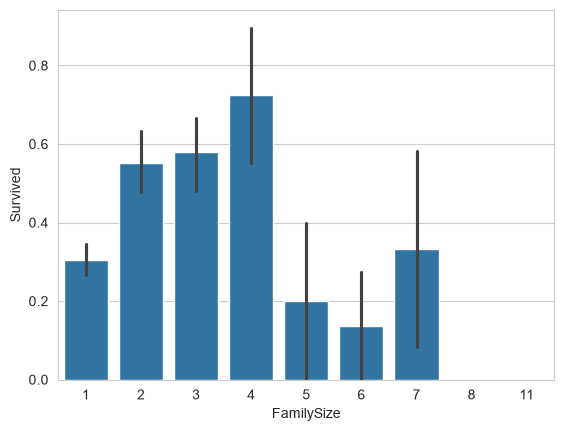

In [58]:
sns.barplot(
    x='FamilySize',
    y='Survived',
    data=df
)
plt.savefig(
    "familySize_survival_rate.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()